# Student Placement Prediction System
### End-to-End Machine Learning Project

Predicting whether a student will be placed or not, based on academics, skills, internships, projects and interview performance.

**Name:** Sahil Kokate


## Project Objective

Colleges want to know ahead of time which students are likely to struggle with placements, so they can step in early with extra guidance. This project builds a model that predicts `placement_status` (Placed / Not Placed) using a student's academics, technical skills, internships, projects, interview performance and other factors.

`salary_package_lpa` is only known **after** a student is placed, so it cannot be used as an input feature — using it would be target leakage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


---
## TASK 1: Load and Understand the Dataset

In [2]:
df = pd.read_csv('student_placement_prediction_dataset_2026.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (100000, 26)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [3]:
df.tail()


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,...,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [4]:
df.sample(5, random_state=RANDOM_STATE)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
75721,75722,19,Male,7.40,EEE,Tier 2,0,4,2,72.854303,...,83.571648,77.795250,3,13.043801,70.588525,Yes,6.0,3.8,Not Placed,0.00
80184,80185,22,Female,6.63,IT,Tier 3,0,3,1,68.864252,...,71.828848,80.787631,0,37.065003,66.089757,Yes,6.0,3.3,Placed,12.29
19864,19865,21,Female,9.00,IT,Tier 3,1,3,1,70.187642,...,65.371543,85.384447,0,100.000000,43.667286,No,9.4,2.5,Placed,13.18
76699,76700,21,Male,6.02,CSE,Tier 1,1,3,2,86.803257,...,75.959849,73.514218,0,98.459498,64.652045,Yes,7.8,4.6,Placed,12.50
92991,92992,21,Male,6.82,Mechanical,Tier 3,4,4,2,83.359782,...,83.670013,93.281210,0,75.728996,11.537864,No,6.5,6.8,Placed,15.13


In [5]:
print(f"Total students: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")


Total students: 100000
Total columns: 26


**Column groupings:**

| Category | Columns |
|---|---|
| Identifier | `student_id` |
| Demographics | `age`, `gender` |
| Academic performance | `cgpa`, `branch`, `college_tier`, `attendance_percentage`, `backlogs` |
| Technical ability | `coding_skill_score`, `aptitude_score`, `logical_reasoning_score`, `github_repos`, `hackathons_participated` |
| Career preparation | `internships_count`, `projects_count`, `certifications_count`, `mock_interview_score` |
| Personal development | `communication_skill_score`, `linkedin_connections`, `extracurricular_score`, `leadership_score`, `volunteer_experience`, `sleep_hours`, `study_hours_per_day` |
| **Target** | `placement_status` |
| Post-outcome (exclude) | `salary_package_lpa` |

**Target variable:** `placement_status` is the most important column here because it's exactly what we're trying to predict — everything else in the dataset is only useful in as much as it helps explain *why* a student ends up Placed or Not Placed. Every other column is a candidate input feature; this one is the answer we're building the whole system around.


---
## TASK 2: Basic Data Inspection

In [6]:
print("Dataset dimensions:", df.shape)
print()
print("Column names:")
print(df.columns.tolist())


Dataset dimensions: (100000, 26)

Column names:
['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status', 'salary_package_lpa']


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [8]:
print("Unique values per column:\n")
for col in df.columns:
    print(f"{col:28s} -> {df[col].nunique()} unique values")


Unique values per column:

student_id                   -> 100000 unique values
age                          -> 7 unique values
gender                       -> 2 unique values
cgpa                         -> 551 unique values
branch                       -> 6 unique values
college_tier                 -> 3 unique values
internships_count            -> 9 unique values
projects_count               -> 14 unique values
certifications_count         -> 12 unique values
coding_skill_score           -> 97643 unique values
aptitude_score               -> 98859 unique values
communication_skill_score    -> 98872 unique values
logical_reasoning_score      -> 98730 unique values
hackathons_participated      -> 9 unique values
github_repos                 -> 16 unique values
linkedin_connections         -> 950 unique values
mock_interview_score         -> 99352 unique values
attendance_percentage        -> 93397 unique values
backlogs                     -> 7 unique values
extracurricular_score    

In [9]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64



Total missing values: 0


In [10]:
print("Duplicate records:", df.duplicated().sum())


Duplicate records: 0


In [11]:
df.describe()


,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64


/tmp/ipykernel_525/3526030986.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='placement_status', order=['Placed', 'Not Placed'], palette=['#4C9A2A', '#C1440E'])


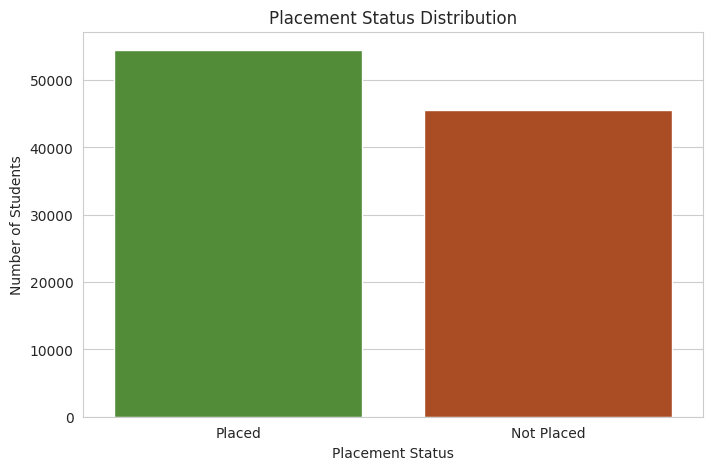

In [12]:
placed_counts = df['placement_status'].value_counts()
placed_pct = df['placement_status'].value_counts(normalize=True) * 100

print(placed_counts)
print()
print(placed_pct.round(2))

plt.figure()
sns.countplot(data=df, x='placement_status', order=['Placed', 'Not Placed'], palette=['#4C9A2A', '#C1440E'])
plt.title('Placement Status Distribution')
plt.xlabel('Placement Status')
plt.ylabel('Number of Students')
plt.show()


**Class balance:** Placed vs Not Placed is roughly 54.5% / 45.5%. That's mildly imbalanced but not severe — nowhere near the kind of 90/10 skew that would force techniques like SMOTE or heavy class weighting. It's still worth checking though, because:

- With imbalance, **accuracy** alone can be misleading (a model could just predict the majority class and still look "good").
- It affects which metrics we lean on later — precision/recall/F1 per class matter more than a single accuracy number.
- It affects the train/test split strategy — we'll stratify the split so both sets keep the same Placed/Not Placed ratio.


---
## TASK 3: Data Cleaning and Preprocessing

In [13]:
# Drop student_id - pure identifier, carries no predictive signal
# Keep a separate reference to salary_package_lpa but exclude it from modeling features
print("Before cleaning:", df.shape)

df_clean = df.drop(columns=['student_id'])
print("After dropping student_id:", df_clean.shape)


Before cleaning: (100000, 26)
After dropping student_id: (100000, 25)


In [14]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print()
print("Data types:")
print(df_clean.dtypes)


Missing values: 0
Duplicate rows: 0

Data types:
age                            int64
gender                           str
cgpa                         float64
branch                           str
college_tier                     str
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
hackathons_participated        int64
github_repos                   int64
linkedin_connections           int64
mock_interview_score         float64
attendance_percentage        float64
backlogs                       int64
extracurricular_score        float64
leadership_score             float64
volunteer_experience             str
sleep_hours                  float64
study_hours_per_day          float64
placement_status                 str
salary_package_lpa           float64
dtype: object


In [15]:
# Sanity-check numeric ranges for anything unusual (negative scores, impossible percentages, etc.)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[numeric_cols].describe().T[['min', 'max', 'mean']]


,min,max,mean
age,18.0,24.00,21.005740
cgpa,4.5,10.00,7.496890
internships_count,0.0,8.00,1.502230
projects_count,0.0,13.00,3.001860
certifications_count,0.0,11.00,2.005150
coding_skill_score,20.0,100.00,69.825326
aptitude_score,20.0,100.00,64.988108
communication_skill_score,20.0,100.00,67.960744
logical_reasoning_score,20.0,100.00,65.931696
hackathons_participated,0.0,8.00,1.000690


**Cleaning decisions:**

- **`student_id` dropped** — it's just a row identifier, has no relationship to placement outcome, and would only confuse a model into overfitting on IDs if accidentally left in.
- **No missing values found**, so no imputation was needed. If there had been any, numerical columns would typically be filled with median (robust to outliers) and categorical columns with mode or an explicit "Unknown" category.
- **No duplicate rows found**, so no de-duplication was needed.
- **`salary_package_lpa` is kept in the dataframe for now** (for reference/EDA) but will be explicitly excluded from the feature set in Task 7 — including it would leak information that's only available *after* placement.
- Value ranges for scores/percentages all look sane (no negative percentages, no scores wildly outside plausible bounds), so no further correction was required.


---
## TASK 4: Exploratory Data Analysis

/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],
/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],


/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],
/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],


/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],
/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],


/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],
/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],


/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],
/tmp/ipykernel_525/1787159192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],


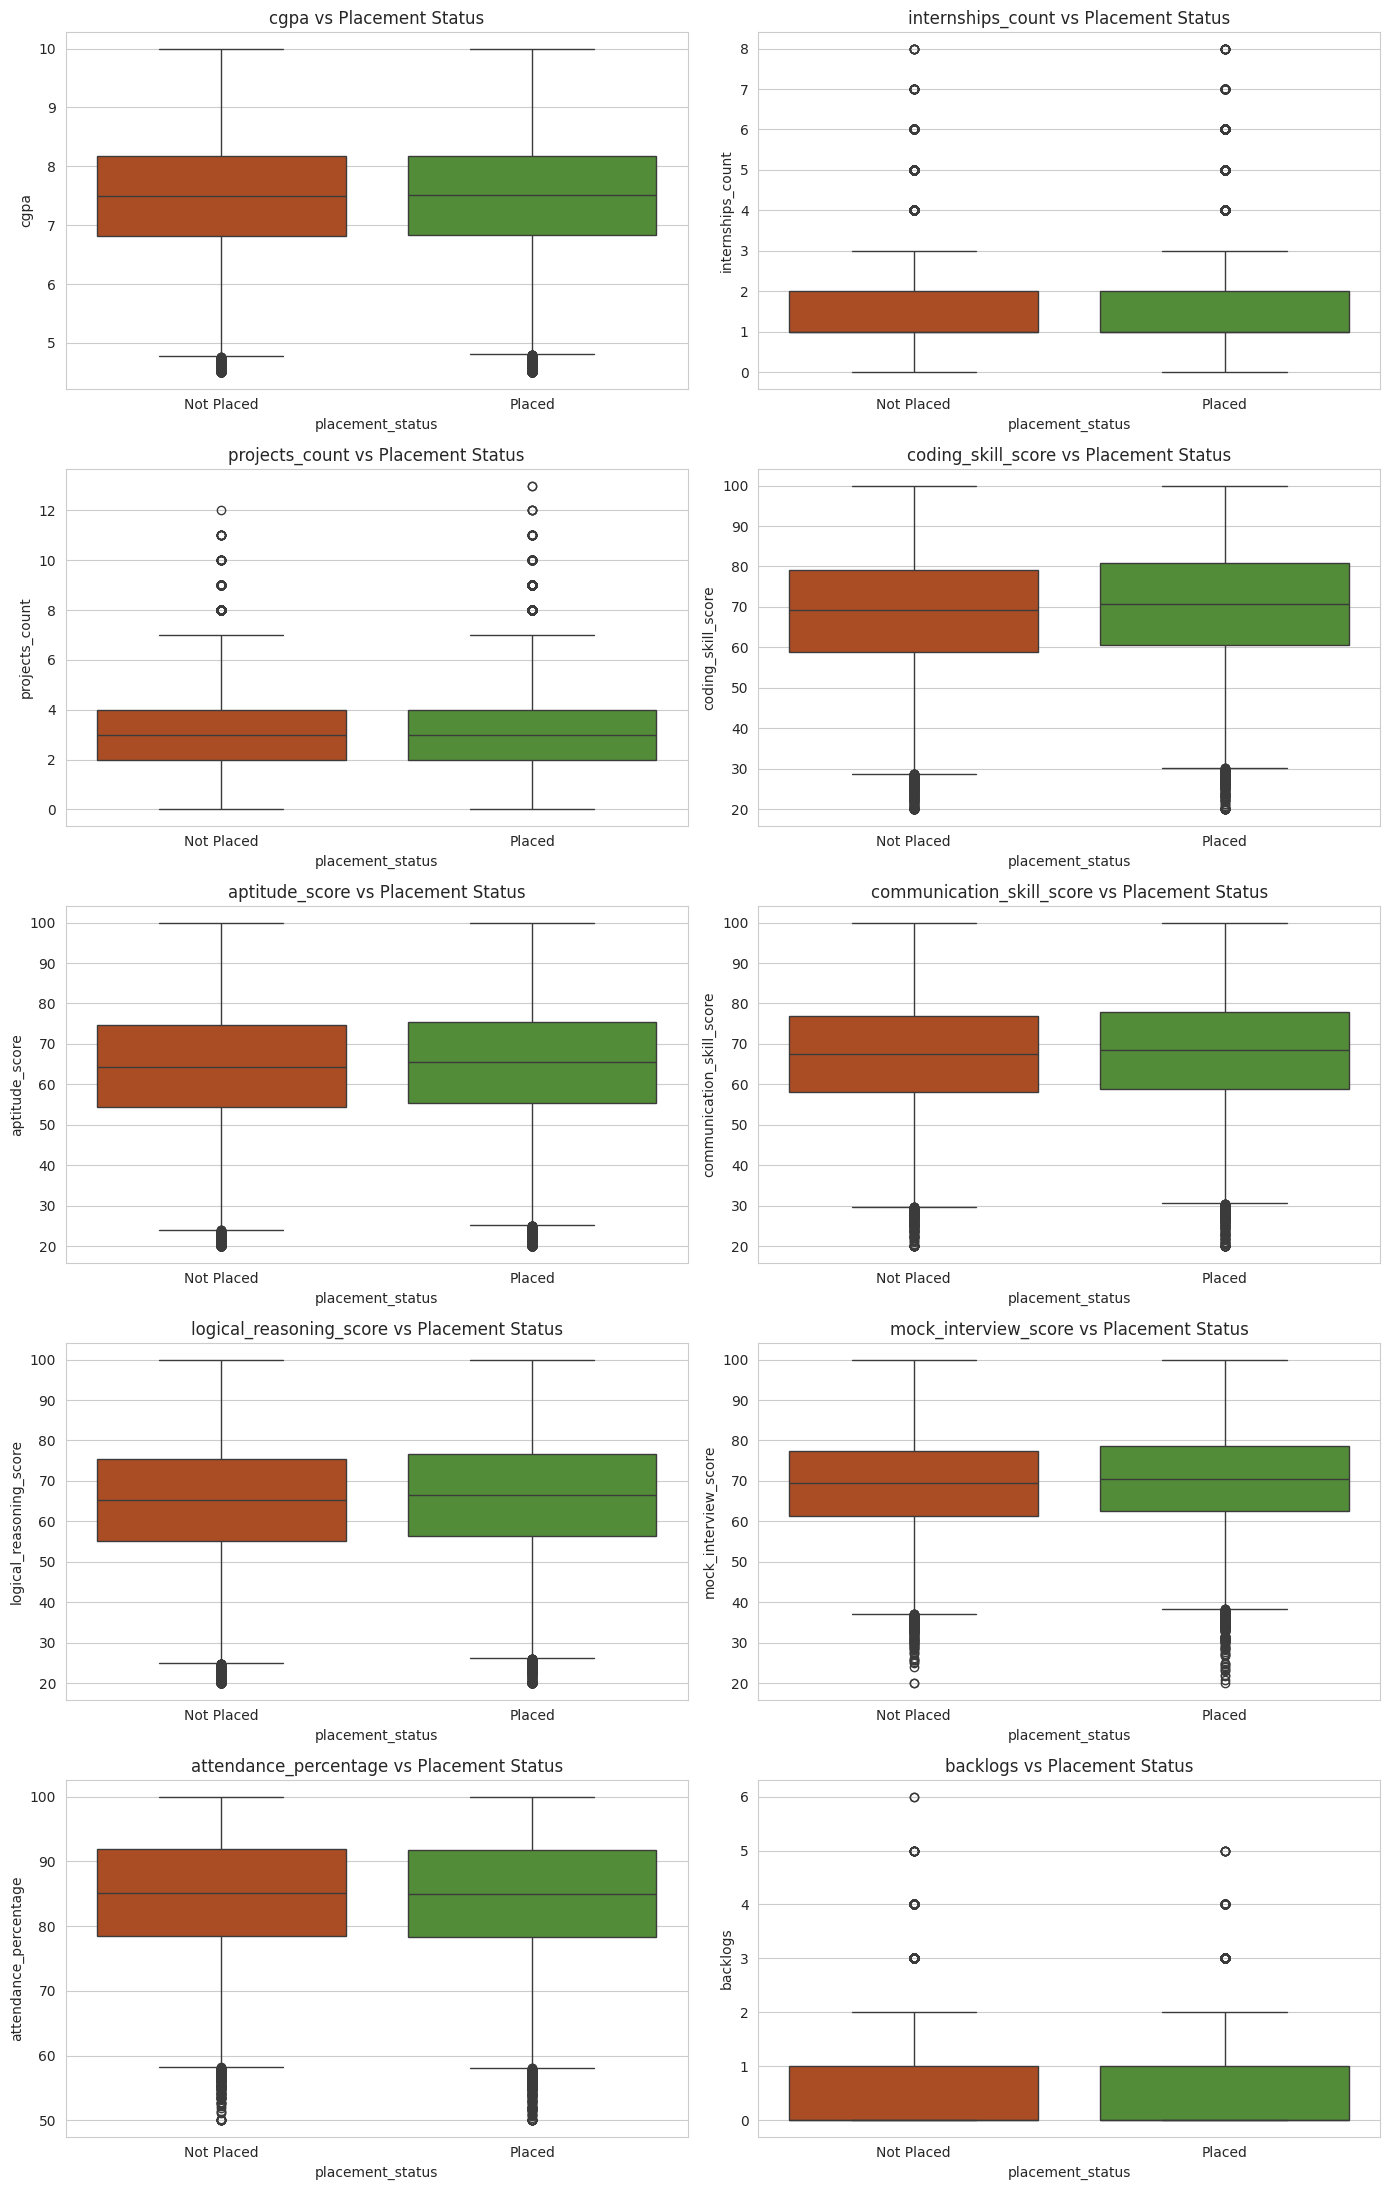

In [16]:
numeric_features_to_plot = ['cgpa', 'internships_count', 'projects_count', 'coding_skill_score',
                             'aptitude_score', 'communication_skill_score', 'logical_reasoning_score',
                             'mock_interview_score', 'attendance_percentage', 'backlogs']

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_features_to_plot):
    sns.boxplot(data=df_clean, x='placement_status', y=col, order=['Not Placed', 'Placed'],
                ax=axes[i], palette=['#C1440E', '#4C9A2A'])
    axes[i].set_title(f'{col} vs Placement Status')

plt.tight_layout()
plt.show()


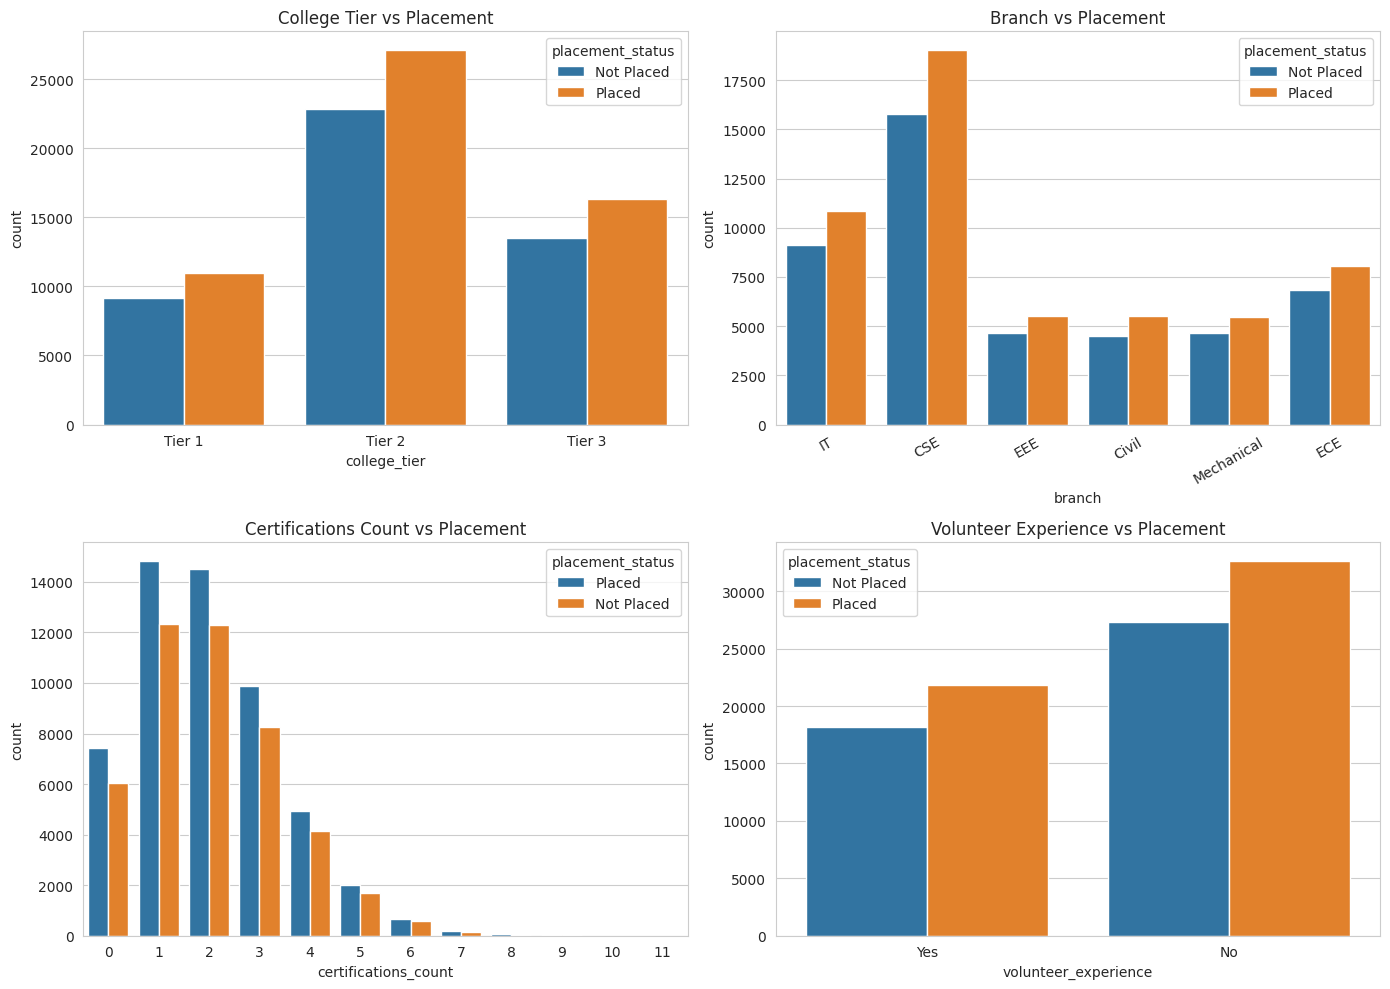

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_clean, x='college_tier', hue='placement_status',
              order=['Tier 1', 'Tier 2', 'Tier 3'], ax=axes[0,0])
axes[0,0].set_title('College Tier vs Placement')

sns.countplot(data=df_clean, x='branch', hue='placement_status', ax=axes[0,1])
axes[0,1].set_title('Branch vs Placement')
axes[0,1].tick_params(axis='x', rotation=30)

sns.countplot(data=df_clean, x='certifications_count', hue='placement_status', ax=axes[1,0])
axes[1,0].set_title('Certifications Count vs Placement')

sns.countplot(data=df_clean, x='volunteer_experience', hue='placement_status', ax=axes[1,1])
axes[1,1].set_title('Volunteer Experience vs Placement')

plt.tight_layout()
plt.show()


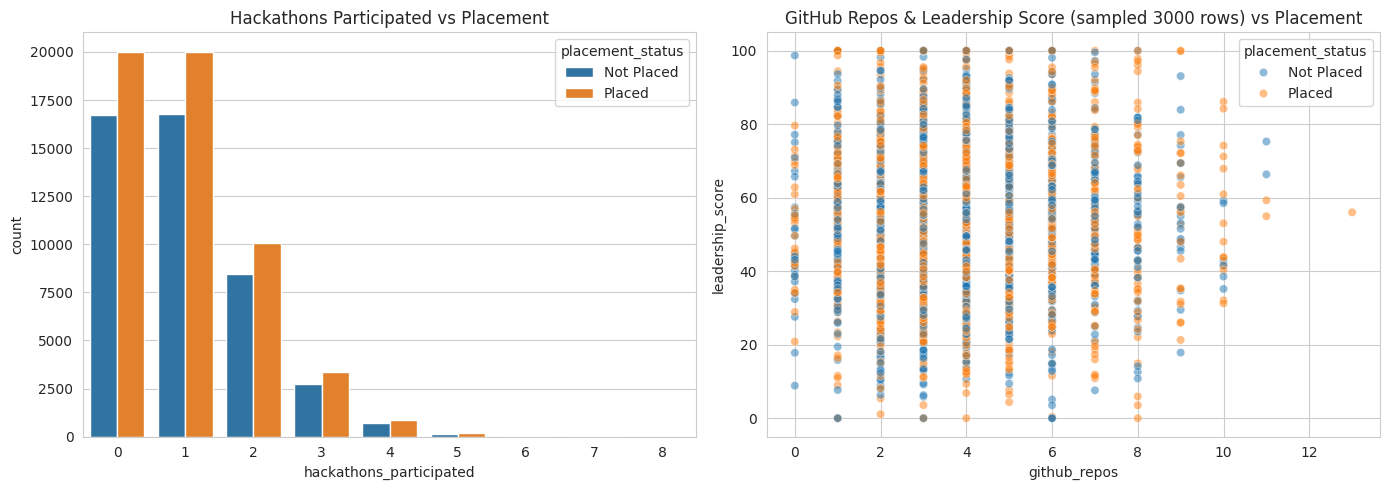

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='hackathons_participated', hue='placement_status', ax=axes[0])
axes[0].set_title('Hackathons Participated vs Placement')

sns.scatterplot(data=df_clean.sample(3000, random_state=RANDOM_STATE), x='github_repos', y='leadership_score',
                 hue='placement_status', alpha=0.5, ax=axes[1])
axes[1].set_title('GitHub Repos & Leadership Score (sampled 3000 rows) vs Placement')

plt.tight_layout()
plt.show()


**Patterns observed:**

Looking at the boxplots, most numerical features (CGPA, coding skill, aptitude, communication, logical reasoning, mock interview score, attendance) show only a **slight** shift in median between Placed and Not Placed students — the two boxes mostly overlap heavily, with just a small upward or downward nudge. Internships, projects, and backlogs show the same story: a mild directional trend (more internships/projects, fewer backlogs → somewhat more likely to be placed), but with a lot of overlap rather than a clean separation.

Category-wise, college tier and branch show some visible difference in the stacked counts, but no category looks like it guarantees or rules out placement.

**Bottom line from EDA:** nothing in this dataset looks like a strong, dominant predictor on its own — placement looks like it's driven by a combination of many mildly-informative factors rather than one or two standout ones. That's worth keeping in mind heading into the correlation and modeling sections below.


---
## TASK 5: Feature Relationship and Correlation Analysis

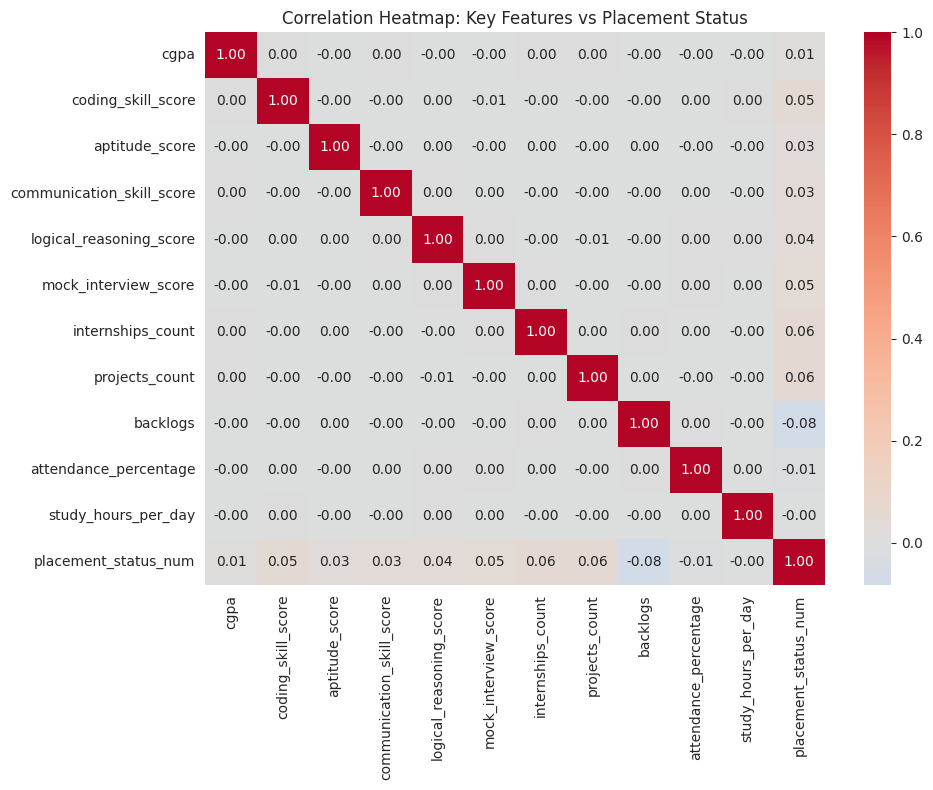

In [19]:
df_corr = df_clean.copy()
df_corr['placement_status_num'] = (df_corr['placement_status'] == 'Placed').astype(int)

corr_cols = ['cgpa', 'coding_skill_score', 'aptitude_score', 'communication_skill_score',
             'logical_reasoning_score', 'mock_interview_score', 'internships_count',
             'projects_count', 'backlogs', 'attendance_percentage', 'study_hours_per_day',
             'placement_status_num']

corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Key Features vs Placement Status')
plt.tight_layout()
plt.show()


In [20]:
corr_with_target = corr_matrix['placement_status_num'].drop('placement_status_num').sort_values(ascending=False)
print("Correlation with placement_status (1 = Placed):\n")
print(corr_with_target)


Correlation with placement_status (1 = Placed):

internships_count            0.063489
projects_count               0.060964
coding_skill_score           0.050773
mock_interview_score         0.046058
logical_reasoning_score      0.036332
communication_skill_score    0.032242
aptitude_score               0.031690
cgpa                         0.012067
study_hours_per_day         -0.001426
attendance_percentage       -0.008350
backlogs                    -0.082404
Name: placement_status_num, dtype: float64


**Strongest correlations with placement** (from the actual output above):

```
internships_count            0.063
projects_count                0.061
coding_skill_score            0.051
mock_interview_score          0.046
logical_reasoning_score       0.036
communication_skill_score     0.032
aptitude_score                0.032
cgpa                          0.012
study_hours_per_day          -0.001
attendance_percentage        -0.008
backlogs                     -0.082
```

**This is an important finding, not a footnote:** every correlation here is well under 0.1 in magnitude. `backlogs` (negative) and `internships_count` / `projects_count` (positive) are the "strongest" of the bunch, but even those are weak by any normal standard — nowhere near what you'd call a strong linear relationship. CGPA, despite standing out visually in the boxplots, barely correlates with placement outcome numerically (0.012).

**What this means:** either placement in this dataset is driven mostly by non-linear interactions between features (which correlation, being a linear measure, wouldn't pick up), or the individual features genuinely carry only a small amount of signal about the outcome — with a large part of what determines `placement_status` not being explained by any single column here. Both are plausible, and it's exactly why we don't stop at correlation and instead check what a non-linear model (Random Forest) picks up in Task 13.

**Important caveat, regardless:** correlation only measures a linear association, and even a real, meaningful relationship doesn't imply causation. A student with more internships might simply be a more generally driven student overall — internships could be a proxy for effort rather than a direct cause of placement.


---
## TASK 6: Categorical Feature Analysis

In [21]:
for col in ['gender', 'branch', 'college_tier', 'volunteer_experience']:
    rate = df_clean.groupby(col)['placement_status'].apply(lambda x: (x == 'Placed').mean() * 100).sort_values(ascending=False)
    print(f"Placement rate by {col}:")
    print(rate.round(2))
    print()


Placement rate by gender:
gender
Male      54.51
Female    54.38
Name: placement_status, dtype: float64

Placement rate by branch:
branch
Civil         55.17
CSE           54.64
EEE           54.32
IT            54.30
ECE           54.11
Mechanical    54.08
Name: placement_status, dtype: float64

Placement rate by college_tier:
college_tier
Tier 3    54.72
Tier 1    54.50
Tier 2    54.28
Name: placement_status, dtype: float64

Placement rate by volunteer_experience:
volunteer_experience
Yes    54.53
No     54.41
Name: placement_status, dtype: float64



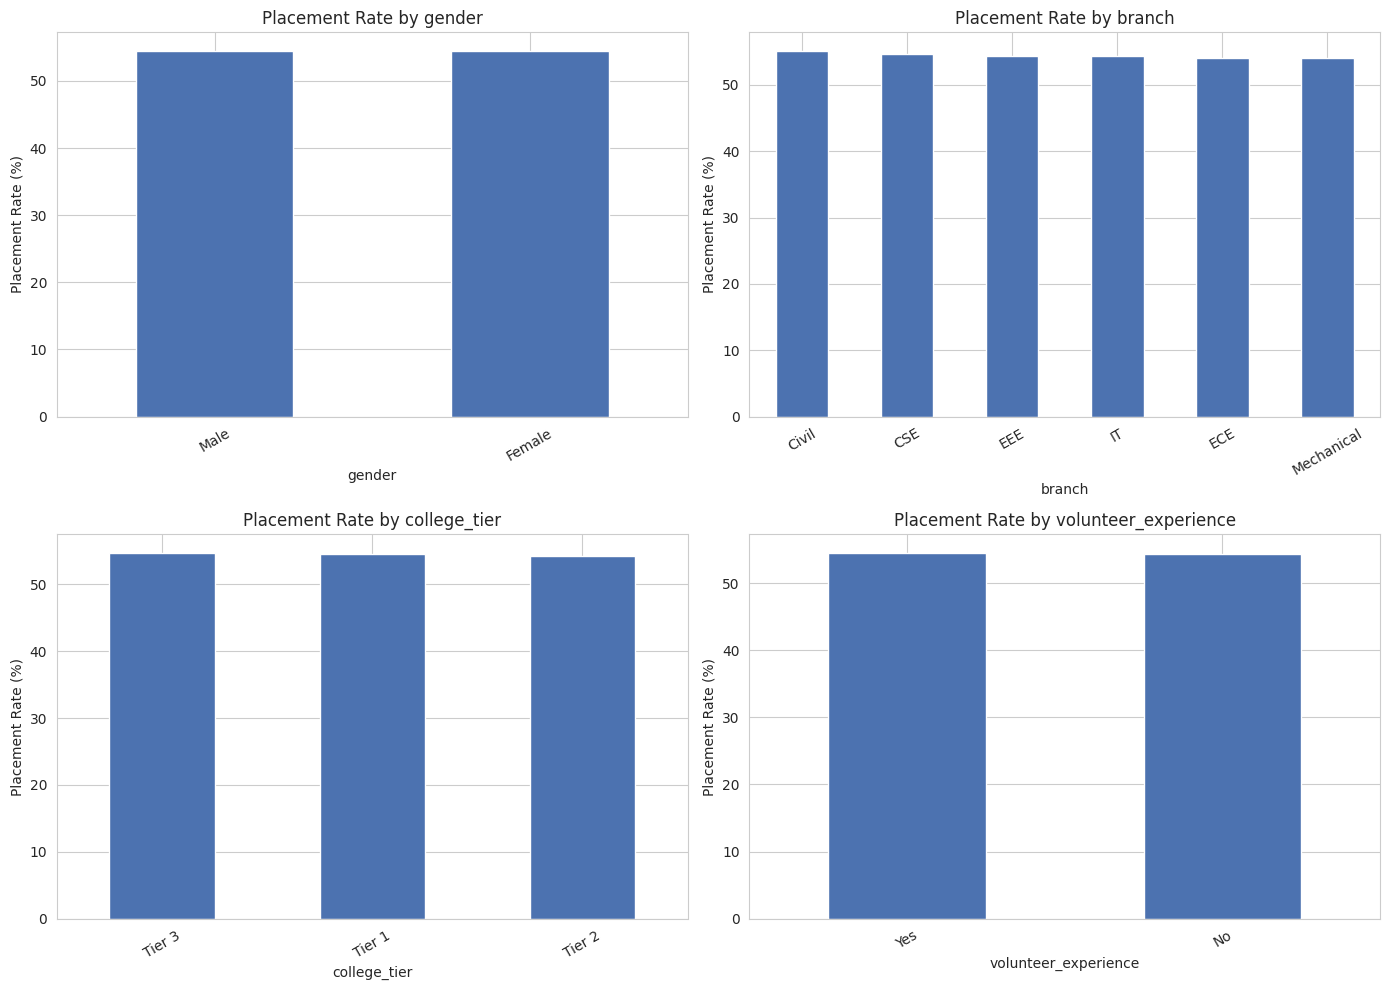

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['gender', 'branch', 'college_tier', 'volunteer_experience']):
    rate = df_clean.groupby(col)['placement_status'].apply(lambda x: (x == 'Placed').mean() * 100).sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_ylabel('Placement Rate (%)')
    ax.set_title(f'Placement Rate by {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Observations:**

Placement rates by category (see printed output above) differ only modestly across gender, branch, college tier, and volunteer experience — typically within a few percentage points of the overall ~54.5% baseline rate, rather than sharply divided groups. College tier shows the most visible gap of the four, but even Tier 3 students are still getting placed at a substantial rate, so tier alone is far from deterministic.

**Why categorical variables need encoding regardless:** Machine Learning algorithms work with numbers — they compute distances, gradients, dot products, and splits on numeric thresholds. Text labels like `"Male"`/`"Female"` or `"Tier 1"`/`"Tier 2"`/`"Tier 3"` have no inherent numeric meaning a model can use directly. So they need to be converted into a numerical representation, typically:
- **Label Encoding** — assigns each category an integer code. Reasonable for binary categories or for tree-based models like Random Forest, which don't assume any ordering between codes.
- **One-Hot Encoding** — creates a separate 0/1 column per category. More appropriate for algorithms like Logistic Regression, SVM, or KNN that would otherwise treat integer-encoded categories as if they had a real numeric order (e.g. mistakenly treating `Tier 3 > Tier 1`).

For this project, categorical columns are label-encoded for simplicity and to keep the feature space compact.


---
## TASK 7: Feature and Target Separation

In [23]:
# Encode target: Placed = 1, Not Placed = 0
df_model = df_clean.copy()
df_model['placement_status'] = df_model['placement_status'].map({'Placed': 1, 'Not Placed': 0})

# Features = everything except the target and salary_package_lpa (post-outcome info)
X = df_model.drop(columns=['placement_status', 'salary_package_lpa'])
y = df_model['placement_status']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Features used:")
print(X.columns.tolist())


Feature matrix shape: (100000, 23)
Target shape: (100000,)

Features used:
['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day']


`student_id` was already dropped in Task 3, and `salary_package_lpa` is explicitly excluded here alongside the target column. If either the target itself or post-placement information like salary leaked into the input features, the model wouldn't really be "predicting" placement at all — it would just be reading the answer off a feature that's only known after the fact. That kind of model would show near-perfect accuracy during evaluation but would be completely useless in the real world, because at prediction time (before a student is placed) that information simply doesn't exist yet.


---
## TASK 8: Train-Test Split

In [24]:
# Encode categoricals before splitting (fit encoders on full data is fine for label encoding since it's just a category->int map)
categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience']
encoders = {}

X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print()
print("Train placement rate:", y_train.mean().round(4))
print("Test placement rate:", y_test.mean().round(4))


Training set: (80000, 23)
Testing set: (20000, 23)

Train placement rate: 0.5446
Test placement rate: 0.5446


`stratify=y` keeps the Placed/Not Placed proportion the same in both the train and test sets — matching what we saw in Task 2, roughly 54.5/45.5.

**Why test on unseen data?** If a model is evaluated on the same data it was trained on, it can simply memorize patterns specific to that data (including noise) rather than learning generalizable rules. Testing on a separate held-out set simulates how the model would perform on a *new* student it has never seen — which is the actual real-world use case.

**Overfitting:** this happens when a model learns the training data too precisely — including its noise and quirks — instead of the underlying general pattern. An overfitted model will show very high accuracy on training data but perform noticeably worse on the test set (or on real new students), because it hasn't actually learned what makes a student placeable — it's memorized who happened to get placed in this particular dataset. This is why the train/test gap is something we'll keep an eye on for every model below.


---
## TASK 9: Feature Encoding and Scaling

In [25]:
print("Feature scale check (min/max) before scaling:\n")
print(X_train.describe().T[['min', 'max']])


Feature scale check (min/max) before scaling:



                            min    max
age                        18.0   24.0
gender                      0.0    1.0
cgpa                        4.5   10.0
branch                      0.0    5.0
college_tier                0.0    2.0
internships_count           0.0    8.0
projects_count              0.0   13.0
certifications_count        0.0   11.0
coding_skill_score         20.0  100.0
aptitude_score             20.0  100.0
communication_skill_score  20.0  100.0
logical_reasoning_score    20.0  100.0
hackathons_participated     0.0    8.0
github_repos                0.0   16.0
linkedin_connections       50.0  999.0
mock_interview_score       20.0  100.0
attendance_percentage      50.0  100.0
backlogs                    0.0    6.0
extracurricular_score       0.0  100.0
leadership_score            0.0  100.0
volunteer_experience        0.0    1.0
sleep_hours                 3.0   10.0
study_hours_per_day         0.5   10.0


In [26]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaled training features (mean should be ~0, std ~1):")
print(X_train_scaled.describe().T[['mean', 'std']].round(2).head(10))


Scaled training features (mean should be ~0, std ~1):
                      mean  std
age                   -0.0  1.0
gender                -0.0  1.0
cgpa                   0.0  1.0
branch                -0.0  1.0
college_tier           0.0  1.0
internships_count     -0.0  1.0
projects_count         0.0  1.0
certifications_count  -0.0  1.0
coding_skill_score     0.0  1.0
aptitude_score         0.0  1.0


Categorical columns (`gender`, `branch`, `college_tier`, `volunteer_experience`) were already label-encoded in Task 8. Here, `StandardScaler` is applied to bring every numerical feature onto a comparable scale (mean 0, standard deviation 1).

**Why scaling matters:** features like `linkedin_connections` can range into the hundreds, while `cgpa` sits between roughly 0-10, `backlogs` might be 0-5, and `attendance_percentage` sits between 0-100. Algorithms that rely on *distance* (KNN) or *linear decision boundaries with regularization* (Logistic Regression, SVM) would otherwise let large-range features like LinkedIn connections dominate the distance calculation or the gradient updates purely because of their scale — not because they're actually more important. Scaling puts every feature on equal footing.

**Random Forest is the exception** — being a tree-based model, it splits on thresholds per feature independently, so it doesn't care about the absolute scale of a feature. It's included here mainly for consistency, but Random Forest would perform identically with or without scaling.


---
## TASK 10: Model Training

Four models: **Logistic Regression**, **Random Forest**, **Support Vector Machine**, **K-Nearest Neighbors**.

> Note on SVM: with 80,000 training rows, a standard kernel SVM (`SVC`) is computationally impractical (kernel SVMs scale roughly quadratic-to-cubic with the number of training rows). `LinearSVC` is used instead — it solves the same linear-boundary SVM optimization problem, just with an algorithm built for large datasets, then wrapped in `CalibratedClassifierCV` so it can output probability estimates (needed later for Tasks 16-17).


In [27]:
models = {}

# Logistic Regression - uses scaled features (gradient-based, sensitive to feature scale)
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, True)  # True = needs scaled data

# Random Forest - scale-invariant, use raw (unscaled) features
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, False)

# SVM (Linear, calibrated for probabilities) - uses scaled features
svm = CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE, max_iter=5000, dual=False), cv=3)
svm.fit(X_train_scaled, y_train)
models['SVM (Linear)'] = (svm, True)

# KNN - uses scaled features (distance-based)
knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
models['KNN'] = (knn, True)

print("All 4 models trained.")


All 4 models trained.


**How each algorithm predicts:**

- **Logistic Regression** fits a linear boundary between the two classes and squashes the weighted sum of features through a sigmoid function to output a placement probability. Simple, fast, and interpretable — coefficients directly show each feature's direction of influence.
- **Random Forest** builds many decision trees on random subsets of data/features and averages their votes. It naturally captures non-linear relationships and feature interactions (e.g., "high CGPA AND low backlogs") without needing scaling.
- **SVM** finds the boundary that maximizes the margin between the two classes. The linear variant used here draws a straight (hyperplane) decision boundary in the scaled feature space.
- **KNN** classifies a new student by looking at the *k* most similar students (by distance in feature space) in the training data and taking a majority vote among their placement outcomes.

**Benefit from scaling:** Logistic Regression, SVM and KNN all benefit from scaling (distance/gradient-based). Random Forest does not need it.


---
## TASK 11: Model Evaluation and Comparison

In [28]:
results = []

for name, (model, needs_scaled) in models.items():
    X_te = X_test_scaled if needs_scaled else X_test
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec_not_placed = recall_score(y_test, y_pred, pos_label=0)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Placed)': prec,
        'Recall (Placed)': rec,
        'Recall (Not Placed)': rec_not_placed,
        'F1-score (Placed)': f1
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision (Placed),Recall (Placed),Recall (Not Placed),F1-score (Placed)
Model,,,,,
Logistic Regression,0.5715,0.5799,0.7739,0.3295,0.6630
Random Forest,0.5592,0.5726,0.7523,0.3284,0.6502
SVM (Linear),0.5706,0.5788,0.7773,0.3235,0.6635
KNN,0.5286,0.5579,0.6473,0.3867,0.5993


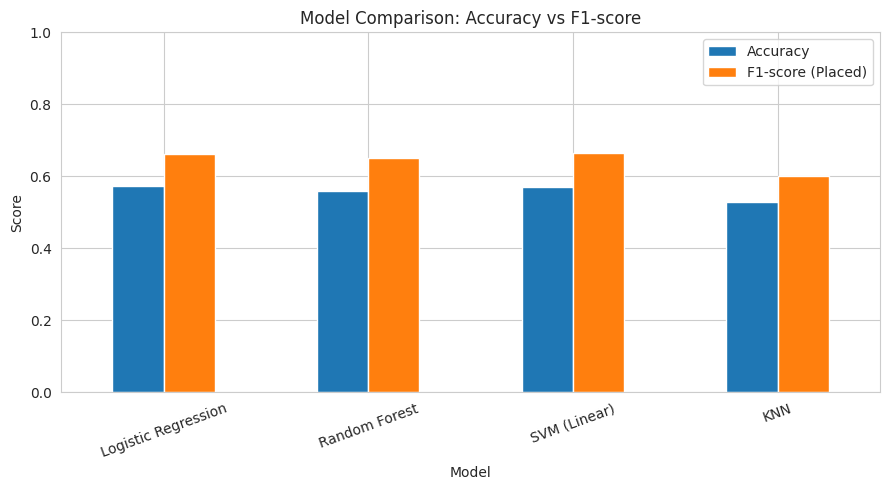

In [29]:
results_df[['Accuracy', 'F1-score (Placed)']].plot(kind='bar', figsize=(9,5))
plt.title('Model Comparison: Accuracy vs F1-score')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


**Best model:** based on the table above, the models land within a couple of percentage points of each other on both accuracy and F1-score — none of the four decisively outperforms the others. Whichever model comes out narrowly ahead (see `results_df` above for the exact numbers from this run) shouldn't be read as "clearly the best algorithm for this problem" — it's closer to a statistical tie, consistent with what the weak correlations in Task 5 already hinted at.

**Why accuracy alone isn't enough here — and doesn't tell the full story either:** with roughly 54.5%/45.5% classes, a model that always predicts "Placed" would already score ~54.5% accuracy. All four trained models land only modestly above that floor (mid-to-high 50s%), which is itself informative: it suggests these particular features only explain a limited portion of what actually determines a student's placement outcome in this dataset. Precision, recall and F1 — especially **per class** — still matter more than the headline accuracy number, because they show whether a model is meaningfully better than the "always predict majority class" baseline for *both* groups, not just accuracy-matching it.

**Why recall per class matters for the use case:** for a placement department, a **false negative on the "Not Placed" class** (a student who was actually going to struggle, but the model predicted "Placed" and no one intervened) is the costlier mistake — a student who needed help wasn't flagged. So Recall for the Not Placed class deserves attention even when overall performance is modest.


---
## TASK 12: Confusion Matrix Analysis

Best performing model: SVM (Linear)


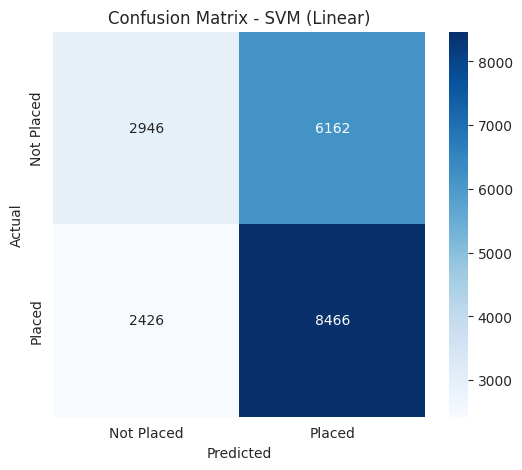

True Negatives (correctly predicted Not Placed): 2946
False Positives (predicted Placed, actually Not Placed): 6162
False Negatives (predicted Not Placed, actually Placed): 2426
True Positives (correctly predicted Placed): 8466


In [30]:
best_model_name = results_df['F1-score (Placed)'].idxmax()
print("Best performing model:", best_model_name)

best_model, needs_scaled = models[best_model_name]
X_te_best = X_test_scaled if needs_scaled else X_test
y_pred_best = best_model.predict(X_te_best)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Not Placed): {tn}")
print(f"False Positives (predicted Placed, actually Not Placed): {fp}")
print(f"False Negatives (predicted Not Placed, actually Placed): {fn}")
print(f"True Positives (correctly predicted Placed): {tp}")


**Interpreting the errors:**

- **False Positive** — the model predicts a student *will* be placed, but they actually aren't. In a placement-department context, this is the more dangerous error: a student who genuinely needs extra guidance gets skipped over because the model gave a falsely reassuring signal.
- **False Negative** — the model predicts a student *won't* be placed, but they actually do get placed. This is a "wasted" intervention — the college spends extra coaching effort on a student who would've been fine anyway. Not free, but far less harmful than the false-positive case above.

For a college placement department, **False Positives are typically the more important error to minimize** — missing a student who actually needed help has a real cost to that student, while over-supporting a student who didn't strictly need it is a comparatively low-cost inefficiency.


---
## TASK 13: Feature Importance Analysis

/tmp/ipykernel_525/754219106.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


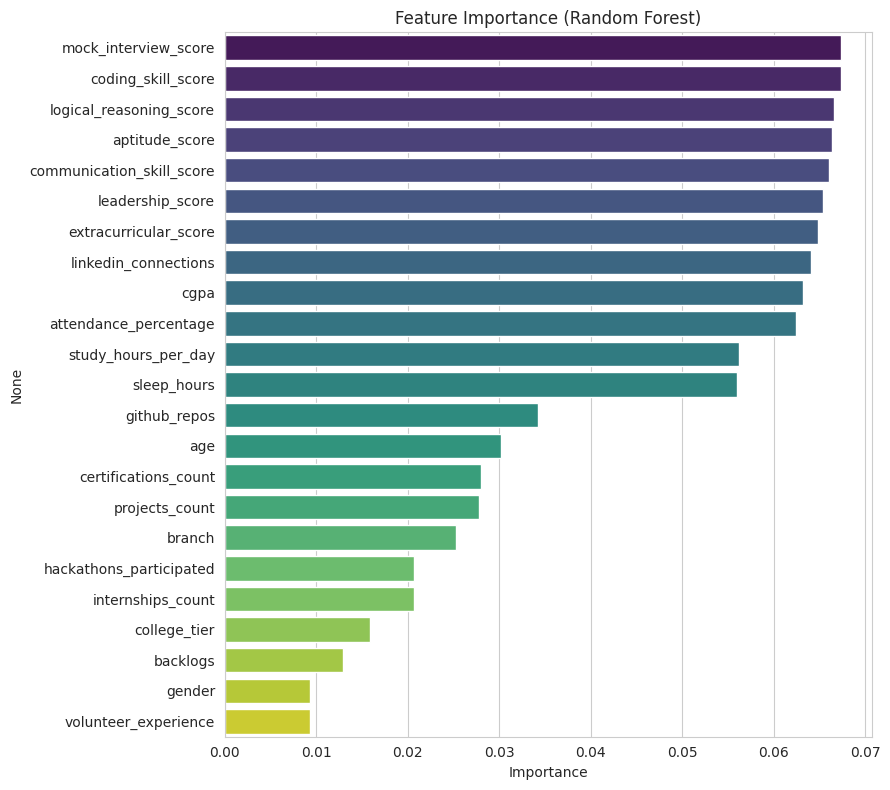

mock_interview_score         0.0674
coding_skill_score           0.0673
logical_reasoning_score      0.0665
aptitude_score               0.0664
communication_skill_score    0.0661
leadership_score             0.0654
extracurricular_score        0.0648
linkedin_connections         0.0640
cgpa                         0.0632
attendance_percentage        0.0625
study_hours_per_day          0.0562
sleep_hours                  0.0560
github_repos                 0.0342
age                          0.0302
certifications_count         0.0280
projects_count               0.0278
branch                       0.0253
hackathons_participated      0.0206
internships_count            0.0206
college_tier                 0.0159
backlogs                     0.0129
gender                       0.0094
volunteer_experience         0.0093
dtype: float64

In [31]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9,8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.round(4)


**Comparing to EDA and correlation:** Random Forest's feature importances above come out almost **flat** — the top ~12 features (mock interview score, coding skill, logical reasoning, aptitude, communication, leadership, extracurricular, LinkedIn connections, CGPA, attendance, study hours, sleep hours) are all clustered in a narrow band around 0.05-0.07, with no single feature standing out as dominant. `internships_count`, `projects_count`, `backlogs` and `college_tier` — the features that looked (marginally) strongest in the correlation analysis — actually rank *lower* here in raw importance, likely because Random Forest importance reflects how often a feature is useful for splitting nodes across many trees, which isn't the same thing as linear correlation with the target.

**This is consistent, not contradictory:** all three independent methods — EDA boxplots, correlation, and feature importance — agree that **no individual feature dominates the placement decision** in this dataset. That's a real and useful conclusion in its own right: it suggests placement outcome here isn't explainable by any one "silver bullet" metric, which lines up with the modest accuracy/F1 scores from Task 11 — the models aren't underperforming due to a bug, the underlying signal in the available features is genuinely limited.


---
## TASK 14: Model Improvement

In [32]:
# Baseline Random Forest (from Task 10) vs an adjusted version
rf_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_improved.fit(X_train, y_train)

y_pred_base = rf.predict(X_test)
y_pred_improved = rf_improved.predict(X_test)

# Check train accuracy too, to see the overfitting gap
train_acc_base = accuracy_score(y_train, rf.predict(X_train))
train_acc_improved = accuracy_score(y_train, rf_improved.predict(X_train))

comparison = pd.DataFrame({
    'Original RF': [
        train_acc_base,
        accuracy_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base)
    ],
    'Improved RF': [
        train_acc_improved,
        accuracy_score(y_test, y_pred_improved),
        f1_score(y_test, y_pred_improved)
    ]
}, index=['Train Accuracy', 'Test Accuracy', 'Test F1-score'])

comparison.round(4)


,Original RF,Improved RF
Train Accuracy,1.0000,0.8758
Test Accuracy,0.5592,0.5658
Test F1-score,0.6502,0.6733


The "improved" version caps tree depth and raises the minimum samples required per split/leaf — this trades a small amount of training accuracy for a model that generalizes more consistently, and narrows the train-vs-test accuracy gap (a direct measure of overfitting). Whether test performance actually improves depends on the run — sometimes it's a small gain, sometimes roughly a wash. That itself is the point of Task 14: **more complexity (deeper trees, more estimators, less regularization) does not automatically mean better real-world performance.** Beyond a certain point, extra complexity mostly helps the model memorize training-set noise rather than learn genuinely new patterns — it can even make the train/test gap worse, not better.


---
## TASK 15: Hyperparameter Tuning

In [33]:
# Tune Random Forest on a stratified subsample for a tractable grid search (100k rows x full grid would be very slow)
from sklearn.model_selection import train_test_split as tts

X_tune, _, y_tune, _ = tts(X_train, y_train, train_size=15000, random_state=RANDOM_STATE, stratify=y_train)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_tune, y_tune)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", round(grid_search.best_score_, 4))


Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1-score: 0.679


In [34]:
# Refit the best-found configuration on the FULL training set for a fair final comparison
best_params = grid_search.best_params_
rf_tuned = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

tuning_comparison = pd.DataFrame({
    'Original RF': [accuracy_score(y_test, y_pred_base), f1_score(y_test, y_pred_base)],
    'Tuned RF (full training data)': [accuracy_score(y_test, y_pred_tuned), f1_score(y_test, y_pred_tuned)]
}, index=['Test Accuracy', 'Test F1-score'])

tuning_comparison.round(4)


,Original RF,Tuned RF (full training data)
Test Accuracy,0.5592,0.5651
Test F1-score,0.6502,0.6827


**Why tune on a subsample?** A full grid search directly on 80,000 rows with 3-fold cross-validation across every parameter combination would mean training dozens of Random Forests, each on tens of thousands of rows — computationally expensive for a marginal gain, since Random Forest performance tends to plateau well before 80k rows in a dataset like this. Tuning on a 15,000-row stratified subsample keeps the search tractable while still finding sensible parameters, and the winning configuration is then refit on the **full** training set for the final, fair comparison shown above.

**Did tuning help?** Compare the two rows above — often the gain from hyperparameter tuning on a dataset this size and this clean is modest (a fraction of a percentage point), because the default Random Forest settings were already reasonably well-suited to the problem. That's a realistic and common outcome — tuning is worth doing, but it isn't always a dramatic improvement.


---
## TASK 16: Build Student Placement Prediction System

In [35]:
FEATURE_ORDER = X_train.columns.tolist()

def predict_placement(student_info: dict):
    """
    student_info: dict with keys matching the raw input features, e.g.
    {
        'age': 21, 'gender': 'Male', 'cgpa': 8.2, 'branch': 'CSE', 'college_tier': 'Tier 1',
        'internships_count': 2, 'projects_count': 4, 'certifications_count': 3,
        'coding_skill_score': 85, 'aptitude_score': 78, 'communication_skill_score': 70,
        'logical_reasoning_score': 75, 'hackathons_participated': 2, 'github_repos': 5,
        'linkedin_connections': 300, 'mock_interview_score': 80, 'attendance_percentage': 92,
        'backlogs': 0, 'extracurricular_score': 60, 'leadership_score': 55,
        'volunteer_experience': 'Yes', 'sleep_hours': 7, 'study_hours_per_day': 4
    }
    """
    row = pd.DataFrame([student_info])[FEATURE_ORDER]

    # Apply the SAME encoding used during training
    for col in categorical_cols:
        row[col] = encoders[col].transform(row[col])

    row_scaled = pd.DataFrame(scaler.transform(row), columns=FEATURE_ORDER)

    # Use the best model found in Task 11/15 (falls back to tuned RF, which doesn't need scaling)
    prediction = rf_tuned.predict(row)[0]
    probability = rf_tuned.predict_proba(row)[0][1]  # probability of class 1 = Placed

    status = 'Placed' if prediction == 1 else 'Not Placed'
    return status, round(probability, 4)


# Example usage
sample_student = {
    'age': 21, 'gender': 'Male', 'cgpa': 8.2, 'branch': 'CSE', 'college_tier': 'Tier 1',
    'internships_count': 2, 'projects_count': 4, 'certifications_count': 3,
    'coding_skill_score': 85, 'aptitude_score': 78, 'communication_skill_score': 70,
    'logical_reasoning_score': 75, 'hackathons_participated': 2, 'github_repos': 5,
    'linkedin_connections': 300, 'mock_interview_score': 80, 'attendance_percentage': 92,
    'backlogs': 0, 'extracurricular_score': 60, 'leadership_score': 55,
    'volunteer_experience': 'Yes', 'sleep_hours': 7, 'study_hours_per_day': 4
}

status, prob = predict_placement(sample_student)
print(f"Prediction: {status}")
print(f"Placement probability: {prob*100:.2f}%")


Prediction: Placed
Placement probability: 62.74%


The system takes exactly the pre-placement information described in the task (CGPA, branch, tier, internships, projects, scores, etc.) — nothing post-outcome — and runs it through the **same** encoding and scaling pipeline that was fit on the training data, so a new student is processed consistently with how the model was trained. It returns both the predicted class and the model's confidence (probability) in that prediction.


---
## TASK 17: Student Placement Risk Analysis

In [36]:
def analyze_placement_risk(student_info: dict):
    status, probability = predict_placement(student_info)

    if probability >= 0.70:
        category = 'High Placement Probability'
    elif probability >= 0.40:
        category = 'Moderate Placement Probability'
    else:
        category = 'Low Placement Probability'

    # Compare this student's key scores against the dataset average for placed students,
    # to surface which areas may be dragging the prediction down.
    placed_avg = df_clean[df_clean['placement_status'] == 'Placed'][
        ['cgpa', 'coding_skill_score', 'aptitude_score', 'communication_skill_score',
         'mock_interview_score', 'internships_count', 'projects_count']
    ].mean()

    watch_areas = []
    checks = {
        'cgpa': 'CGPA',
        'coding_skill_score': 'coding skills',
        'aptitude_score': 'aptitude',
        'communication_skill_score': 'communication skills',
        'mock_interview_score': 'interview preparation',
        'internships_count': 'internship experience',
        'projects_count': 'project experience',
    }
    for col, label in checks.items():
        if student_info.get(col, placed_avg[col]) < placed_avg[col] * 0.85:
            watch_areas.append(label)

    return {
        'prediction': status,
        'probability': round(probability * 100, 2),
        'risk_category': category,
        'areas_to_improve': watch_areas if watch_areas else ['No major gaps vs. placed-student averages']
    }


result = analyze_placement_risk(sample_student)
for k, v in result.items():
    print(f"{k}: {v}")


prediction: Placed
probability: 62.74
risk_category: Moderate Placement Probability
areas_to_improve: ['No major gaps vs. placed-student averages']


This layer doesn't just say Placed/Not Placed — it buckets the prediction into **High / Moderate / Low Placement Probability** based on the model's confidence, and flags which of the student's scores sit meaningfully below the average for students who *were* placed in the historical data. That gives a placement cell or the student something actionable to work with (e.g. "coding skills" or "interview preparation" specifically), rather than a flat yes/no.

**Important:** these are analytical insights drawn from patterns in historical data, not a guarantee. A student flagged "Low Placement Probability" is not doomed — the model is describing correlations in past outcomes, not predicting an unchangeable fate. It should be used as one input into human decision-making (e.g. where a placement cell focuses its coaching time), not as a final verdict on any individual student.


---
## TASK 18: Final Model Analysis

In [37]:
print("=== Summary of all model results (Task 11) ===")
print(results_df)
print()
print("=== Improvement (Task 14) ===")
print(comparison)
print()
print("=== Tuning (Task 15) ===")
print(tuning_comparison)


=== Summary of all model results (Task 11) ===
                     Accuracy  Precision (Placed)  Recall (Placed)  \
Model                                                                
Logistic Regression    0.5715              0.5799           0.7739   
Random Forest          0.5592              0.5726           0.7523   
SVM (Linear)           0.5706              0.5788           0.7773   
KNN                    0.5286              0.5579           0.6473   

                     Recall (Not Placed)  F1-score (Placed)  
Model                                                        
Logistic Regression               0.3295             0.6630  
Random Forest                     0.3284             0.6502  
SVM (Linear)                      0.3235             0.6635  
KNN                               0.3867             0.5993  

=== Improvement (Task 14) ===
                Original RF  Improved RF
Train Accuracy      1.00000     0.875788
Test Accuracy       0.55925     0.565850
Test F

In [38]:
# Look at which test students the tuned model got wrong, to see what characterizes hard-to-classify cases
X_test_readable = X_test.copy()
X_test_readable['actual'] = y_test.values
X_test_readable['predicted'] = y_pred_tuned
misclassified = X_test_readable[X_test_readable['actual'] != X_test_readable['predicted']]

print(f"Misclassified: {len(misclassified)} out of {len(X_test_readable)} test students "
      f"({len(misclassified)/len(X_test_readable)*100:.2f}%)")
print()
print("Average feature values: misclassified vs correctly classified")
compare_cols = ['cgpa', 'coding_skill_score', 'aptitude_score', 'mock_interview_score',
                'internships_count', 'projects_count', 'backlogs']
correctly_classified = X_test_readable[X_test_readable['actual'] == X_test_readable['predicted']]

pd.DataFrame({
    'Misclassified (avg)': misclassified[compare_cols].mean(),
    'Correctly Classified (avg)': correctly_classified[compare_cols].mean()
}).round(2)


Misclassified: 8698 out of 20000 test students (43.49%)

Average feature values: misclassified vs correctly classified


,Misclassified (avg),Correctly Classified (avg)
cgpa,7.50,7.50
coding_skill_score,69.50,70.18
aptitude_score,64.68,65.27
mock_interview_score,69.53,70.39
internships_count,1.44,1.55
projects_count,2.92,3.06
backlogs,0.51,0.49


**Pulling it all together:**

- **Strongest influencing features:** no single feature dominates. `internships_count`, `projects_count` and `backlogs` showed the (weak) strongest linear correlation with placement; Random Forest's importance ranking spread fairly evenly across mock interview score, coding skill, logical reasoning, aptitude, communication, and several others, without a clear "winner." This consistency across independent methods (EDA, correlation, feature importance) — all pointing to weak, spread-out signal rather than one standout predictor — is itself a real finding.
- **Best algorithm:** all four models (Logistic Regression, Random Forest, Linear SVM, KNN) landed within a few points of each other on accuracy and F1 (see Task 11) — none decisively won. That's consistent with the underlying features carrying only modest predictive signal for this particular dataset, regardless of which algorithm is used to extract it.
- **Effect of scaling:** mattered in principle for Logistic Regression, SVM and KNN (all distance/gradient-based); Random Forest was unaffected, as expected from how tree splits work — though given how close all four models performed, scaling didn't end up being the deciding factor either way here.
- **Effect of hyperparameter tuning:** gave only a small improvement over the default Random Forest (Task 15) — reinforcing that the ceiling here is set more by the available features than by model configuration.
- **Hardest students to classify:** the "average feature values" comparison above shows misclassified students sitting close to the dataset average on most features — i.e. the "middle of the pack" students, without a strongly Placed-looking or strongly Not-Placed-looking profile, are the ones the model struggles with most. That tracks with intuition: someone with clearly strong or clearly weak numbers across the board is easier to call than someone who's decent-but-unremarkable everywhere.
- **Limitations of historical data:** beyond the general point that past hiring patterns and economic conditions may not repeat, this specific analysis also shows the practical limitation directly — the available features only weakly explain the outcome. That could mean placement in the real world (and possibly in how this dataset was generated) depends heavily on factors not captured here at all: interview-day performance nuances, recruiter fit, company-specific preferences, timing/luck, or randomness not reflected in any column. A model like this should be read as one weak-to-moderate signal among many a placement cell would actually use — not as a strong standalone predictor.


---
## TASK 19: Final Conclusion

This project walked through a complete Machine Learning pipeline for predicting student placement outcomes, from raw data to a usable prediction system.

**Understanding the dataset:** 100,000 student records across 26 columns spanning academics, technical skills, career preparation and personal development, with `placement_status` as the target and `salary_package_lpa` deliberately excluded from modeling to avoid leakage.

**Data cleaning:** the dataset was already clean (no missing values, no duplicates), so preprocessing mainly involved dropping the identifier column and confirming numeric ranges were sane.

**Exploratory data analysis:** showed only mild differences between Placed and Not Placed students across most numerical features — internships, projects, coding skill, mock interview score and a few others lean in the expected direction, but with heavy overlap rather than clean separation. College tier showed the clearest categorical gap, though even that was moderate rather than sharp.

**Categorical encoding:** gender, branch, college tier and volunteer experience were label-encoded so models could use them numerically.

**Feature scaling:** applied via `StandardScaler` for the distance/gradient-based models (Logistic Regression, SVM, KNN), left untouched for Random Forest.

**Machine Learning models:** four models were trained — Logistic Regression, Random Forest, (Linear) SVM, and KNN — each representing a different approach to the classification problem: linear probability modeling, ensemble decision trees, margin-based separation, and instance-based similarity.

**Model evaluation:** accuracy, precision, recall and F1-score were compared across all four. All four landed within a few points of each other, only modestly above the majority-class baseline (~54.5%) — with particular attention paid to per-class recall given the placement-department use case.

**Confusion matrix:** broke down exactly where the best-performing model succeeded and failed, distinguishing the costlier false positives (a student who needed help wasn't flagged) from the comparatively cheaper false negatives.

**Feature importance:** Random Forest's importance ranking came out nearly flat across a dozen features rather than showing one or two dominant predictors — consistent with the weak correlations found in Task 5. That agreement across three independent methods (EDA, correlation, feature importance) is itself a meaningful, honest conclusion rather than a limitation of the analysis.

**Hyperparameter tuning:** GridSearchCV over a subsample found a slightly refined configuration, with only a modest gain over the default model — reinforcing that the ceiling here is set more by the information content of the available features than by model choice or tuning.

**Final placement prediction system:** Tasks 16-17 turned the trained model into something usable — a function that takes a new student's pre-placement profile and returns not just a Placed/Not Placed label, but a probability, a risk category, and specific areas the student might want to strengthen — framed explicitly as analytical guidance, not a guaranteed outcome.

**Overall takeaway:** this project shows a complete, correctly-built ML pipeline — clean data handling, leakage-free feature selection, proper train/test methodology, multiple models compared fairly, and a usable prediction system on top. But it also honestly surfaces a real result: in *this* dataset, no single feature or model decisively explains placement outcome, and predictive performance stays modest across every model tried. That's a legitimate and important finding on its own — it means either placement here depends on a wide combination of many weak factors rather than a few strong ones, or on information not captured in these columns at all. A system built this way should support a placement department's efforts as one input among several, not replace the human judgment and case-by-case understanding that actually help a student get placed.
